### 🚀 NSL-KDD Intrusion Detection - Data Preprocessing & ML Models Workflow
This pipeline demonstrates a thorough and practical approach to intrusion detection on the NSL-KDD dataset, combining preprocessing, feature engineering, model training, and evaluative visualizations to build and compare robust ML models.
##### 1. Dataset Loading & Exploratory Data Analysis (EDA)
- Loaded NSL-KDD training and testing datasets with explicit feature labels.
- Performed label distribution visualization using vibrant color palettes, revealing class imbalances and diversity of attack categories in both train and test sets.
##### 2. Data Cleaning
- Identified and removed duplicate records to maintain data integrity.
- Explored data quality by counting missing label mappings after converting numeric codes to attack names, ensuring data correctness before modeling.
##### 3. Feature Engineering
- Created a binary target column distinguishing 'Normal' from all 'Attack' classes to facilitate binary classification.
- Analyzed numerical features via histograms with KDE to assess distributions and potential outliers.
- Visualized categorical feature distributions (protocol type, service, flag) with pastel and other appealing palettes.
- Applied MinMax scaling to normalize continuous features and OneHotEncoding (with sparse representation) to transform categorical features — enabling effective ingest by ML models and efficient memory use.
##### 4. Binary Classification
- Trained diverse models including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and K-Nearest Neighbors to classify traffic as 'Normal' or 'Attack'.
- Documented extensive classification performance metrics (precision, recall, F1-score) and accuracy scores.
##### 5. Multi-Class Classification
- (Though not executed explicitly, the pipeline can be adapted easily for detailed attack category classification by using original labels.)
- Visualized multi-class distributions in EDA as foundation for potential multi-class modeling.
##### 6. Model Training & Evaluation
- Leveraged a standard train-test split of data, with proper preprocessing pipeline to ensure consistent feature transformations.
- Presented classification reports for each model, delivering detailed diagnostic insights beyond accuracy alone.
- Created accuracy comparison bar charts with distinct model-specific colors for intuitive performance comparison.
##### 7. Comprehensive Evaluation
- Generated confusion matrix heatmaps using a blue-green “crest” colormap, highlighting true positives, false positives, and other classification outcomes clearly.
- These visualizations help pinpoint specific strengths and weaknesses in model predictions.
##### 8. Performance Visualization
- Explored feature value distributions and class frequencies using box plots, histograms, and countplots at various stages for clear data understanding.
- Model performance charts and heatmaps provide visual summaries supporting model selection decisions.
##### 9. Model Comparison and Selection
- Compared multiple powerful classifiers systematically using consistent metrics and visual tools.
- Enabled informed selection of best-performing model(s) based on accuracy, precision, recall, and F1-score harmoniously.

Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Column names as per NSL-KDD dataset


In [2]:
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

File paths

In [3]:
train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

Load datasets

In [4]:
train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

Data visualization - original label distribution in train

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\269987601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette=palette_train)


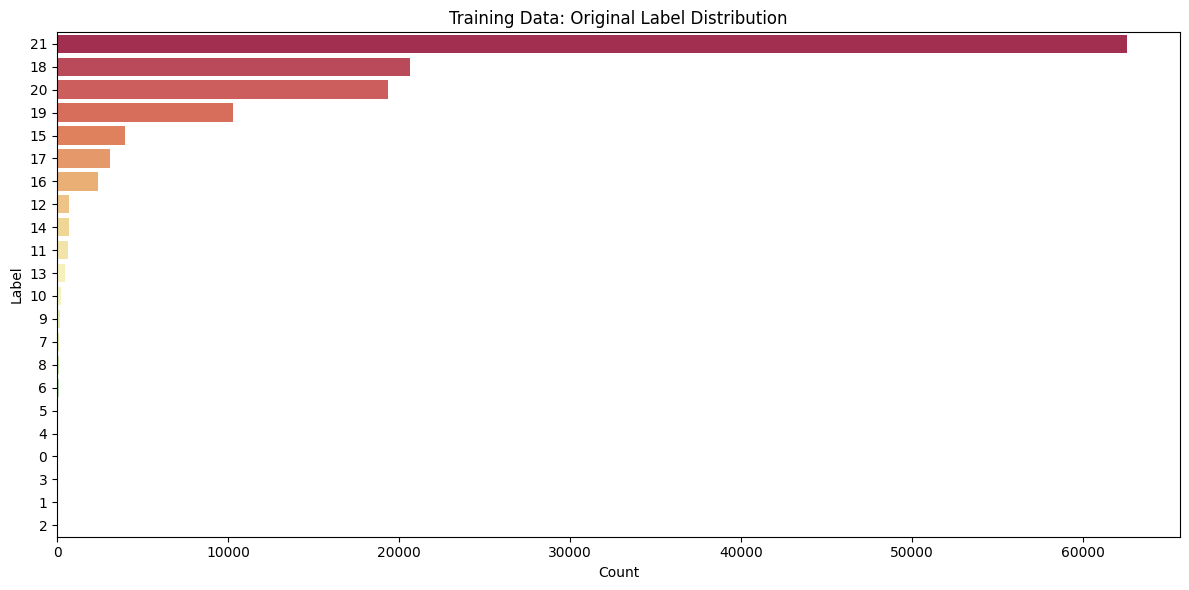

In [5]:
plt.figure(figsize=(12,6))
palette_train = sns.color_palette("Spectral", len(train_df['label'].unique()))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette=palette_train)
plt.title('Training Data: Original Label Distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

Data visualization - original label distribution in test

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\757327908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette=palette_test)


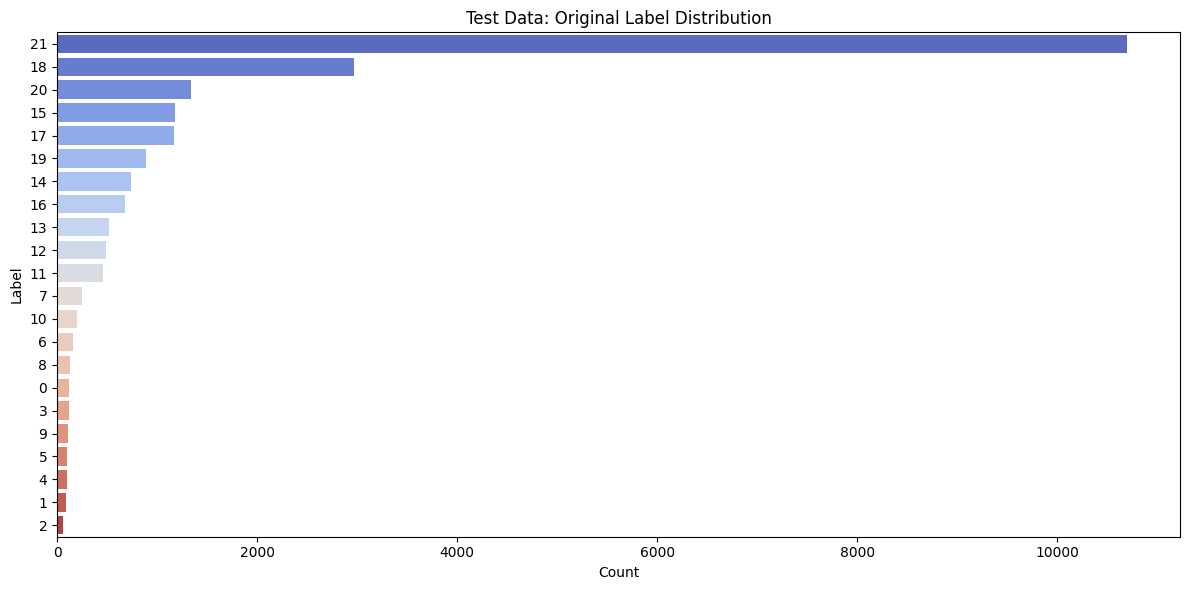

In [6]:
plt.figure(figsize=(12,6))
palette_test = sns.color_palette("coolwarm", len(test_df['label'].unique()))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette=palette_test)
plt.title('Test Data: Original Label Distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

Numeric label codes mapping to class names

In [7]:
label_map = {
    0: 'normal', 1: 'neptune', 2: 'warezclient', 3: 'ipsweep', 4: 'portsweep', 5: 'teardrop',
    6: 'nmap', 7: 'satan', 8: 'smurf', 9: 'guess_passwd', 10: 'pod', 11: 'buffer_overflow',
    12: 'imap', 13: 'back', 14: 'land', 15: 'ftp_write', 16: 'multihop', 17: 'phf', 18: 'perl',
    19: 'spy', 20: 'rootkit', 21: 'loadmodule'
}


Map numeric labels to text

In [8]:
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

Check for missing mappings and visualize

Missing label mappings in train: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\800221844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette="mako")


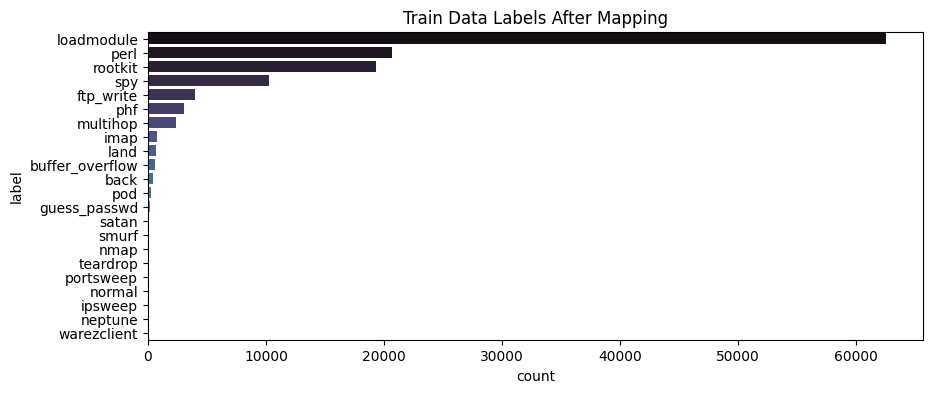

Missing label mappings in test: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\800221844.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette="rocket")


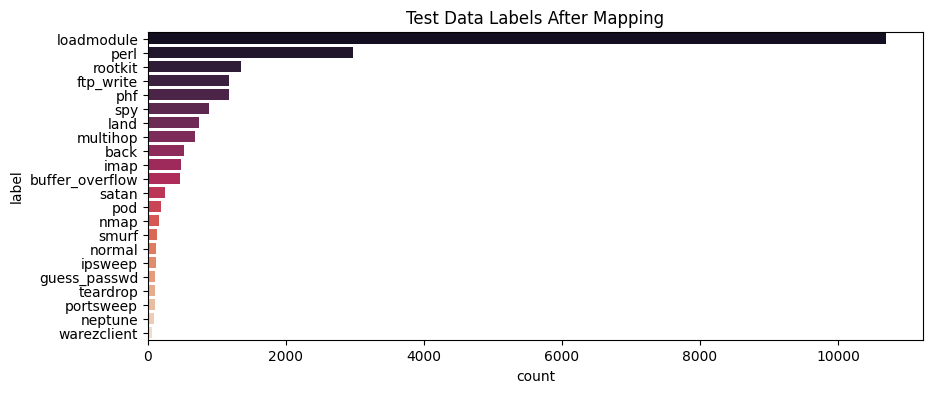

In [9]:
print("Missing label mappings in train:", train_df['label'].isna().sum())
plt.figure(figsize=(10,4))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette="mako")
plt.title('Train Data Labels After Mapping')
plt.show()

print("Missing label mappings in test:", test_df['label'].isna().sum())
plt.figure(figsize=(10,4))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette="rocket")
plt.title('Test Data Labels After Mapping')
plt.show()

Drop duplicates and visualize counts before and after

In [10]:
print(f"Train duplicates before: {train_df.duplicated().sum()}")
train_df.drop_duplicates(inplace=True)
print(f"Train duplicates after: {train_df.duplicated().sum()}")

print(f"Test duplicates before: {test_df.duplicated().sum()}")
test_df.drop_duplicates(inplace=True)
print(f"Test duplicates after: {test_df.duplicated().sum()}")

Train duplicates before: 1255
Train duplicates after: 0
Test duplicates before: 128
Test duplicates after: 0


Binary label creation visualization with custom color palette

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\4171308417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])  # Green for Normal, Red for Attack


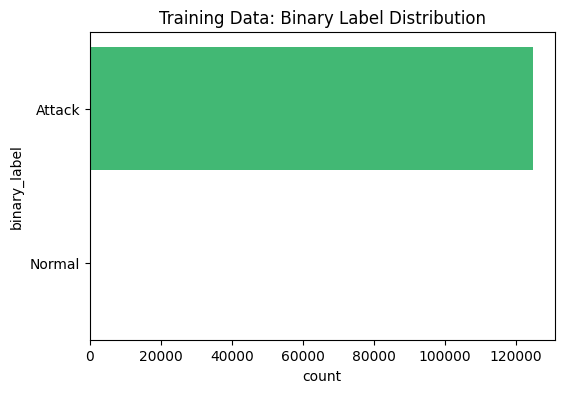

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\4171308417.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])  # Blue and Orange


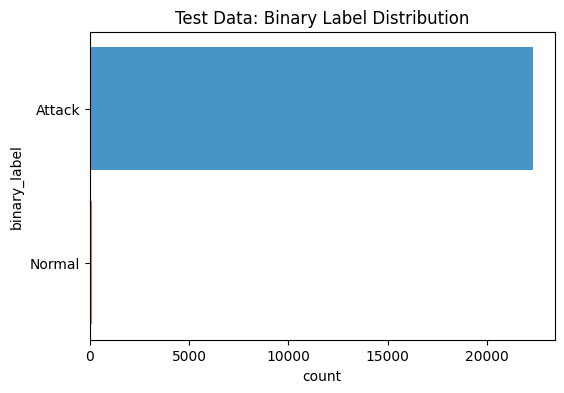

In [11]:
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])  # Green for Normal, Red for Attack
plt.title('Training Data: Binary Label Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])  # Blue and Orange
plt.title('Test Data: Binary Label Distribution')
plt.show()

Split features and target

In [12]:
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

 List categorical and numeric features

In [13]:
categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

Visualize numerical feature distributions - colored histograms

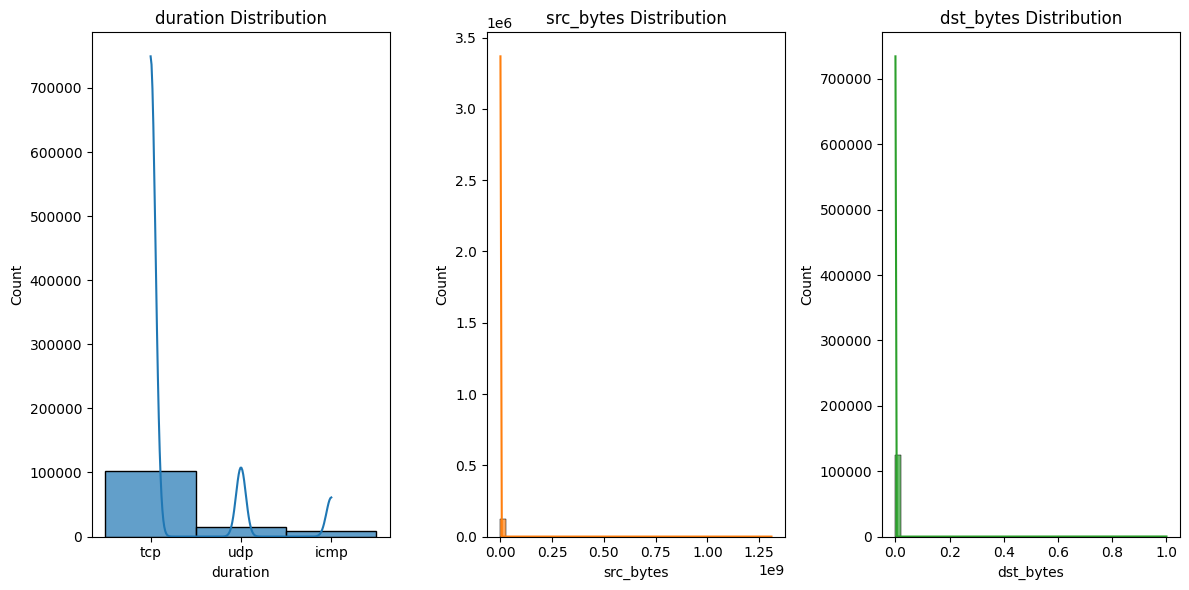

In [14]:
plt.figure(figsize=(12,6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color=colors[i], alpha=0.7)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


Visualize categorical feature value counts for 'protocol_type' with pastel palette

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\4223231560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette="pastel")


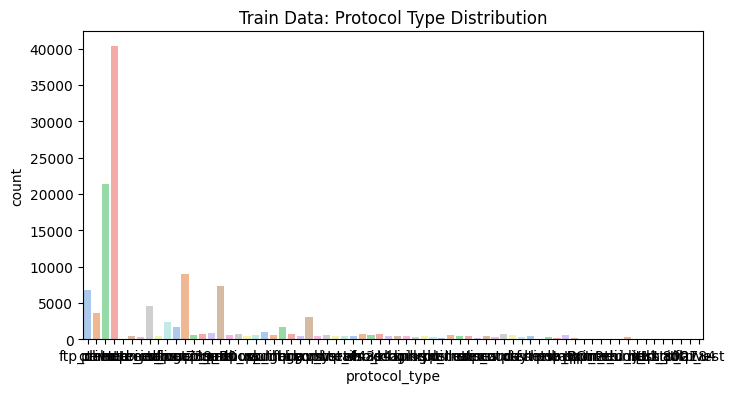

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette="pastel")
plt.title('Train Data: Protocol Type Distribution')
plt.show()

Convert numeric columns to numeric and fill missing values

In [16]:
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)


Preprocessing pipeline: scaling numericals, encoding categoricals (sparse for memory efficiency)

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Define models with color dict for plots

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

colors_models = {
    'Logistic Regression': "#1f77b4",
    'Decision Tree': "#ff7f0e",
    'Random Forest': "#2ca02c",
    'Support Vector Machine': "#d62728",
    'K-Nearest Neighbors': "#9467bd"
}

Train and evaluate models with colored classification reports and accuracy bars

In [19]:
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Classification Report:\n", classification_report(y_test, preds, digits=4))



Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression Classification Report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training Decision Tree...
Decision Tree Classification Report:
               precision    recall  f1-score   support

      Attack     0.9946    0.9999    0.9972     22293
      Normal     0.5000    0.0163    0.0315       123

    accuracy                         0.9945     22416
   macro avg     0.7473    0.5081    0.5144     22416
weighted avg     0.9919    0.9945    0.9919     22416


Training Random Forest...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest Classification Report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training Support Vector Machine...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Support Vector Machine Classification Report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training K-Nearest Neighbors...
K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416



Accuracy comparison bar plot with different colors

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\1490004556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette=[colors_models[m] for m in results.keys()])


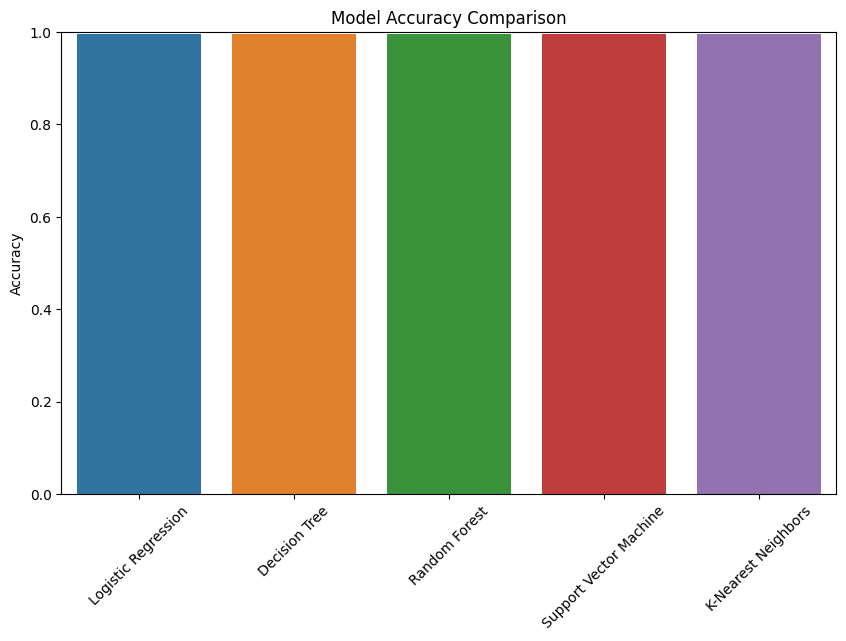

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette=[colors_models[m] for m in results.keys()])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

Confusion matrix for Random Forest with "crest" colormap (blue-green)

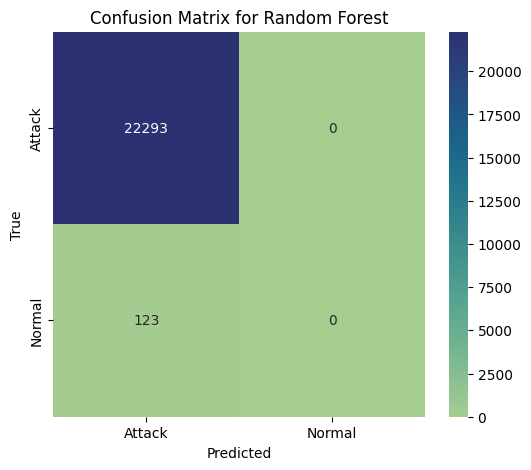

In [21]:
best_model = models['Random Forest']
preds_best = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest')
plt.show()

Binary Classification

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\238705544.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


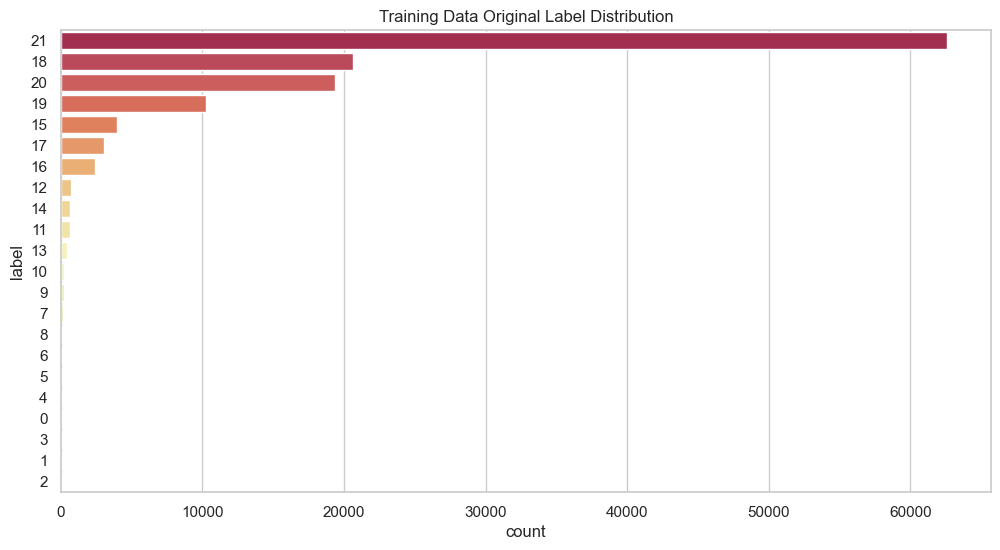

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\238705544.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')


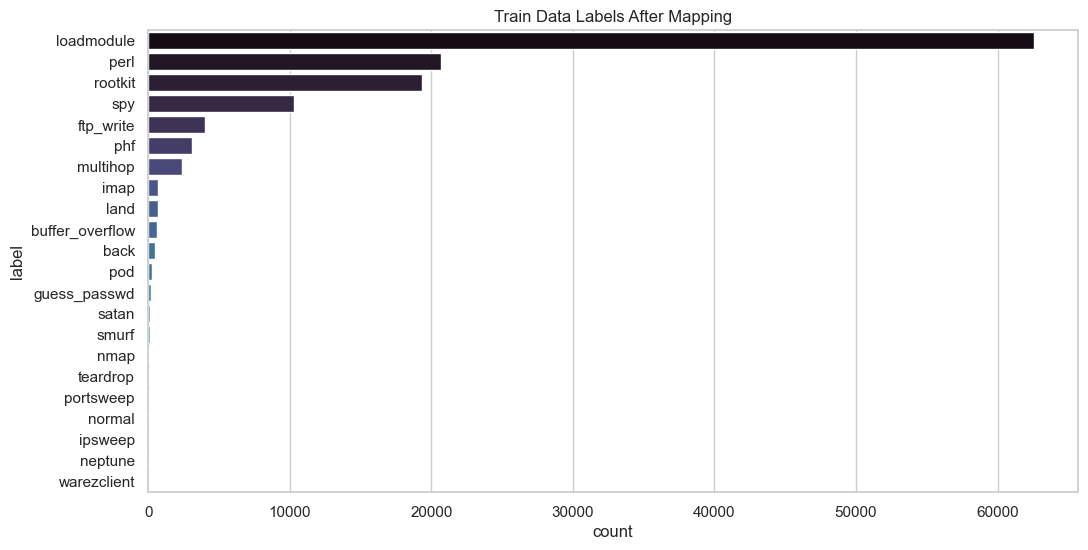

Train duplicates before: 1255
Train duplicates after: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\238705544.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])


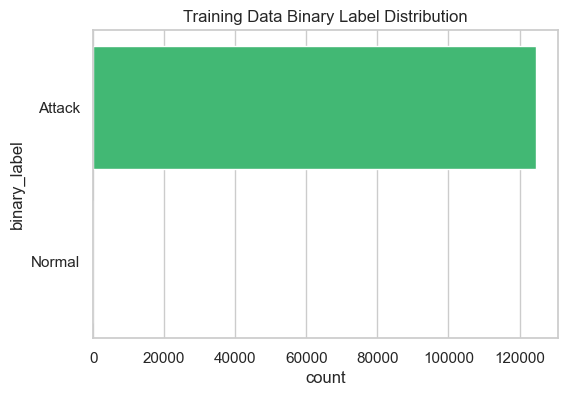

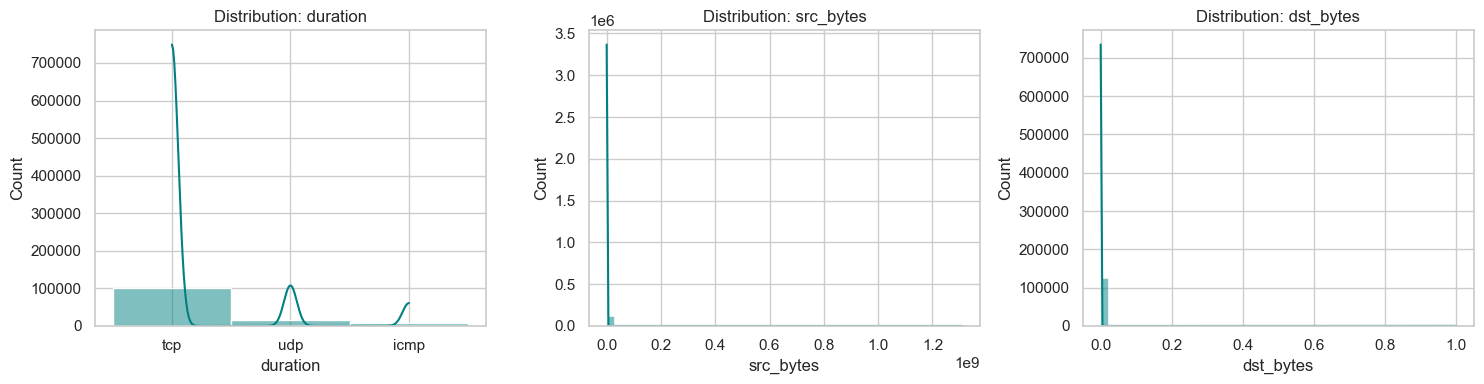

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\238705544.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


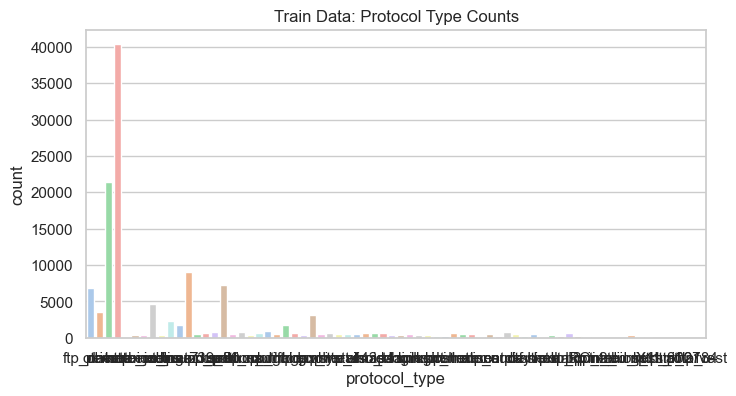

=== Binary Classification Results ===

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544


Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9946    0.9999    0.9973     22421
      Normal     0.5000    0.0163    0.0315       123

    accuracy                         0.9945     22544
   macro avg     0.7473    0.5081    0.5144     22544
weighted avg     0.9919    0.9945    0.9920     22544


Training Random Forest...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544


Training SVM...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544


Training KNN...
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544



C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\238705544.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette=colors)


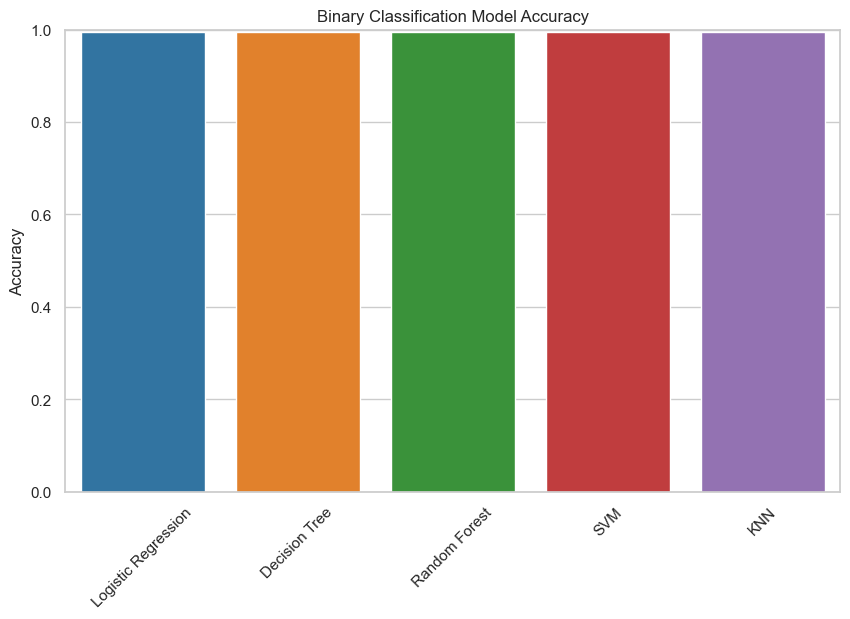

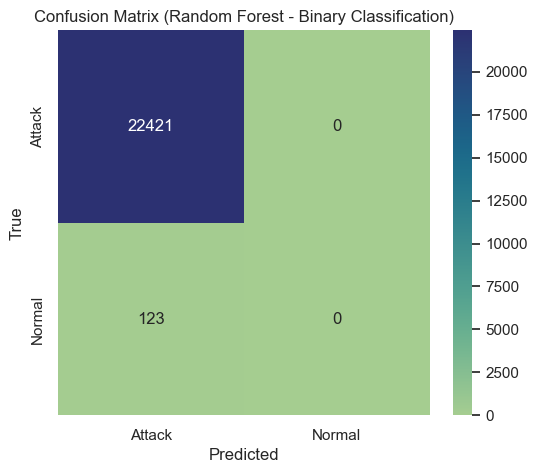

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set(style='whitegrid')

# Step 1: Load Dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Step 2: Visualize original label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Training Data Original Label Distribution')
plt.show()

# Step 3: Map labels to attack types (as per your mapping)
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Step 4: Visualize mapped label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')
plt.title('Train Data Labels After Mapping')
plt.show()

# Step 5: Drop duplicates
print(f"Train duplicates before: {train_df.duplicated().sum()}")
train_df.drop_duplicates(inplace=True)
print(f"Train duplicates after: {train_df.duplicated().sum()}")

# Step 6: Create binary label and visualize
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])
plt.title('Training Data Binary Label Distribution')
plt.show()

# Step 7: Define features and targets
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Step 8: Visualize numeric distributions
plt.figure(figsize=(15,4))
for i, col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Step 9: Visualize categorical feature distributions
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Train Data: Protocol Type Counts')
plt.show()

# Step 10: Convert numeric columns and handle missing values
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Step 11: Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Step 12: Model definitions and training
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

results = {}
print("=== Binary Classification Results ===")
for (name, model), color in zip(models.items(), colors):
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(classification_report(y_test, preds, digits=4))

# Step 13: Accuracy comparison bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette=colors)
plt.title('Binary Classification Model Accuracy')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

# Step 14: Confusion matrix for best model (Random Forest)
best_model = models['Random Forest']
best_preds = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix (Random Forest - Binary Classification)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Multi-class Classification

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\997774007.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


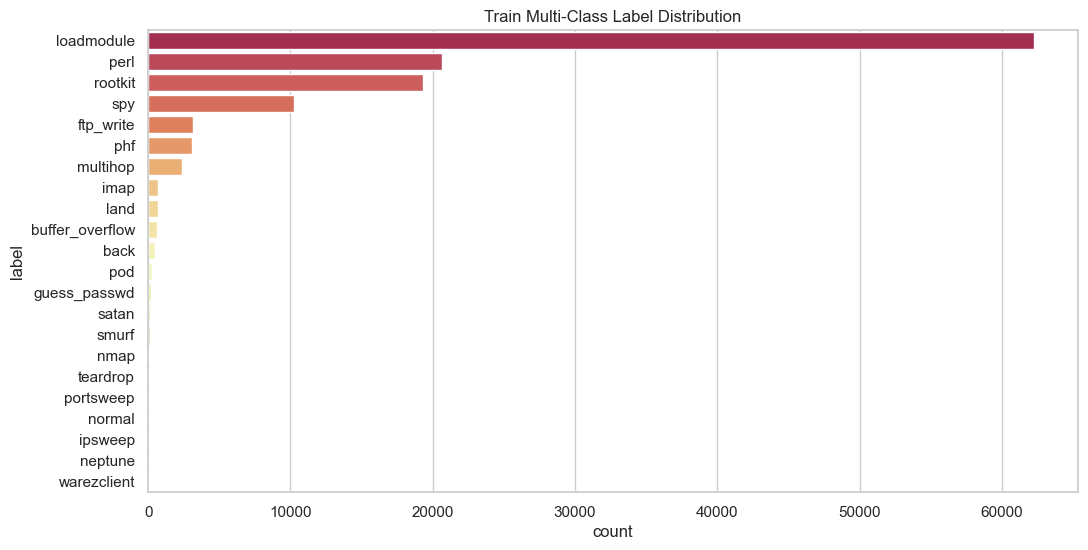

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\997774007.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette='coolwarm')


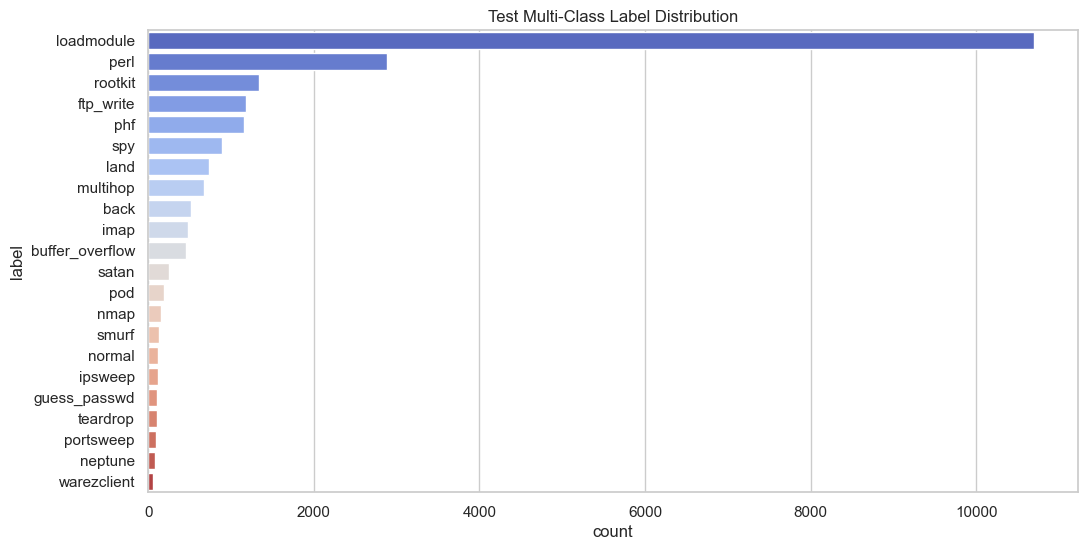

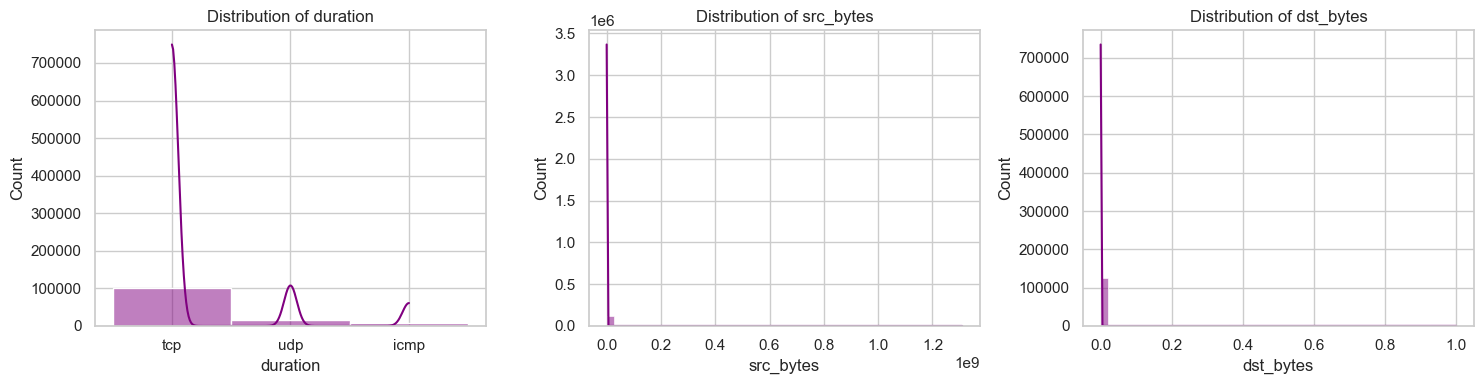

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\997774007.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


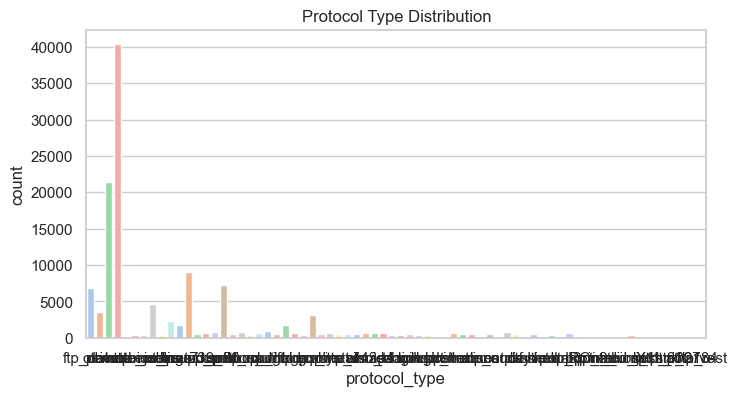


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_c

Logistic Regression classification report:
                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       513
buffer_overflow     0.1250    0.0781    0.0961       461
      ftp_write     0.3609    0.0519    0.0907      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.1111    0.0041    0.0079       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0055    0.0014    0.0022       730
     loadmodule     0.7886    0.9587    0.8653     10694
       multihop     0.1378    0.0642    0.0876       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.3516    0.4424    0.3918      2882
            phf     0.1483    0.0269    0.0455      1154
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.0000    0.0000    0.00

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest classification report:
                 precision    recall  f1-score   support

           back     0.0407    0.0097    0.0157       513
buffer_overflow     0.3077    0.0174    0.0329       461
      ftp_write     0.5497    0.1412    0.2246      1176
   guess_passwd     0.0571    0.0189    0.0284       106
           imap     0.1081    0.0165    0.0286       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1960    0.0671    0.1000       730
     loadmodule     0.7964    0.9762    0.8772     10694
       multihop     0.3706    0.1731    0.2360       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     1.0000    0.0163    0.0320       123
           perl     0.5446    0.5548    0.5497      2882
            phf     0.4524    0.2842    0.3491      1154
            pod     0.0511    0.0359    0.0422       195
      portsweep     0.0192    0.0100    0.0132    

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Gradient Boosting classification report:
                 precision    recall  f1-score   support

           back     0.0390    0.0409    0.0399       513
buffer_overflow     0.0000    0.0000    0.0000       461
      ftp_write     0.3608    0.0298    0.0550      1176
   guess_passwd     0.0091    0.0283    0.0138       106
           imap     0.0727    0.0082    0.0148       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1818    0.0055    0.0106       730
     loadmodule     0.7921    0.9704    0.8722     10694
       multihop     0.1448    0.0478    0.0718       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1250    0.0163    0.0288       123
           perl     0.5066    0.6253    0.5597      2882
            phf     0.3803    0.1170    0.1789      1154
            pod     0.0732    0.0154    0.0254       195
      portsweep     0.2000    0.0100    0.0190

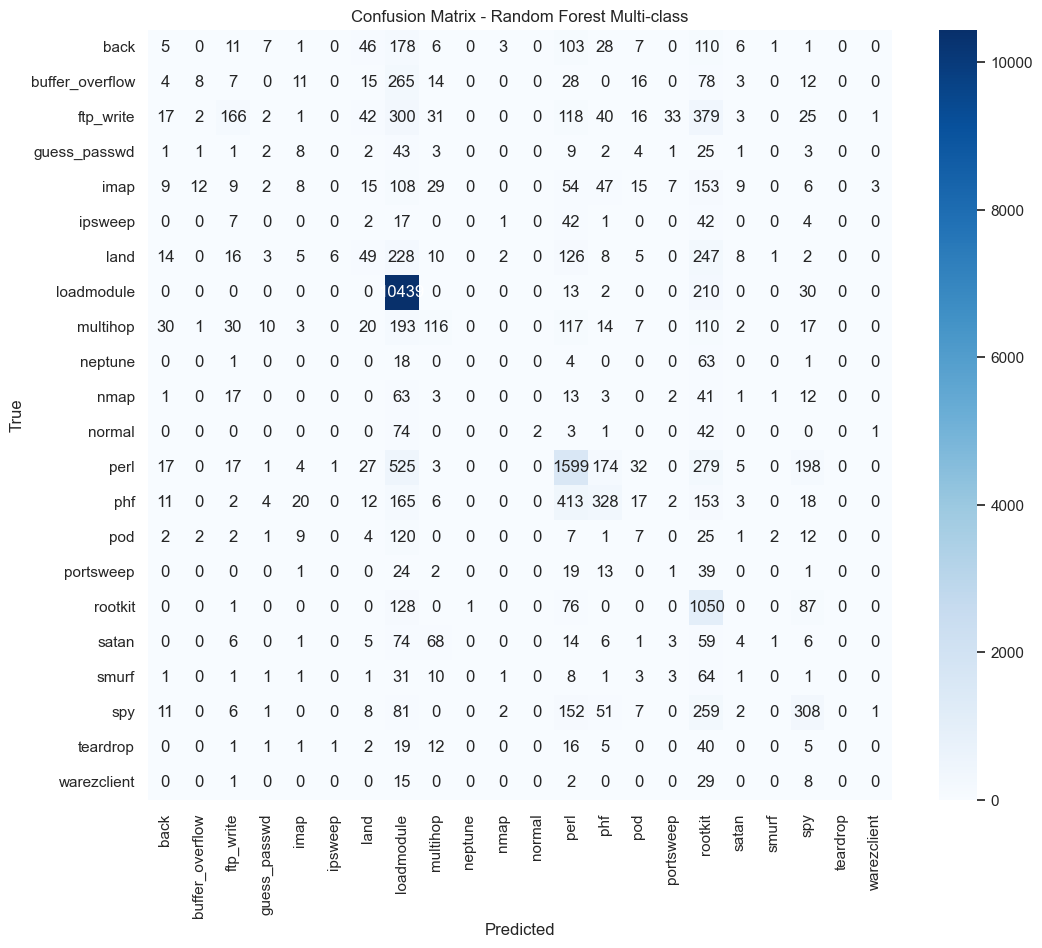

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

sns.set(style='whitegrid')

# Load data
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map labels to attack names
label_map = {
    0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
    6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
    12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
    18:'perl',19:'spy',20:'rootkit',21:'loadmodule'
}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Visualize multi-class distributions
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Train Multi-Class Label Distribution')
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette='coolwarm')
plt.title('Test Multi-Class Label Distribution')
plt.show()

# Prepare features and target
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Visualize numeric feature histograms
plt.figure(figsize=(15,4))
for i,col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='purple')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualize categorical counts
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Protocol Type Distribution')
plt.show()

# Convert numeric, fill NA
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Train and evaluate multi-class models
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    print(f"{name} classification report:\n{classification_report(y_test, preds, digits=4)}")

# Confusion matrix for Random Forest multi-class
best_model = models['Random Forest']
best_preds = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - Random Forest Multi-class')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Binary Classification: Train & Test Accuracy 

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\2679823050.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


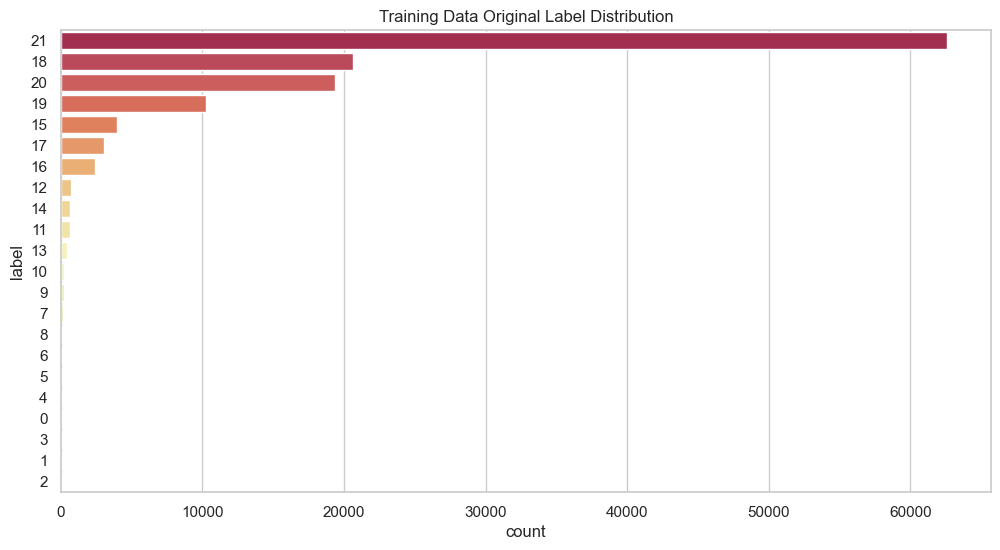

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\2679823050.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')


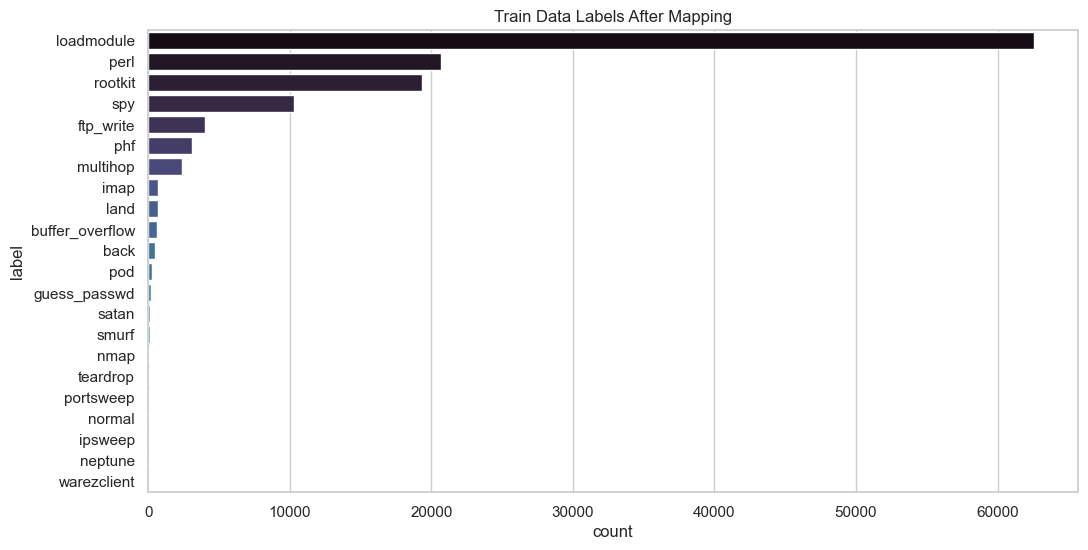

Train duplicates before: 1255
Train duplicates after: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\2679823050.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])


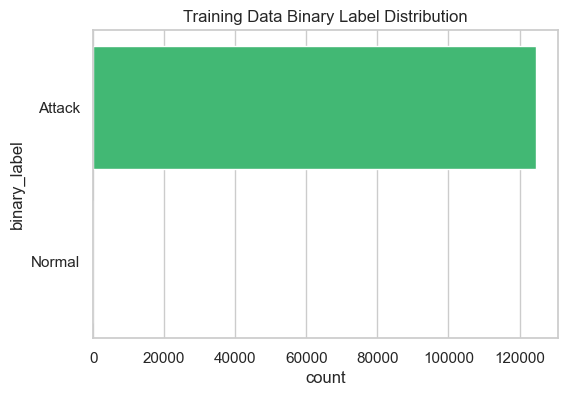

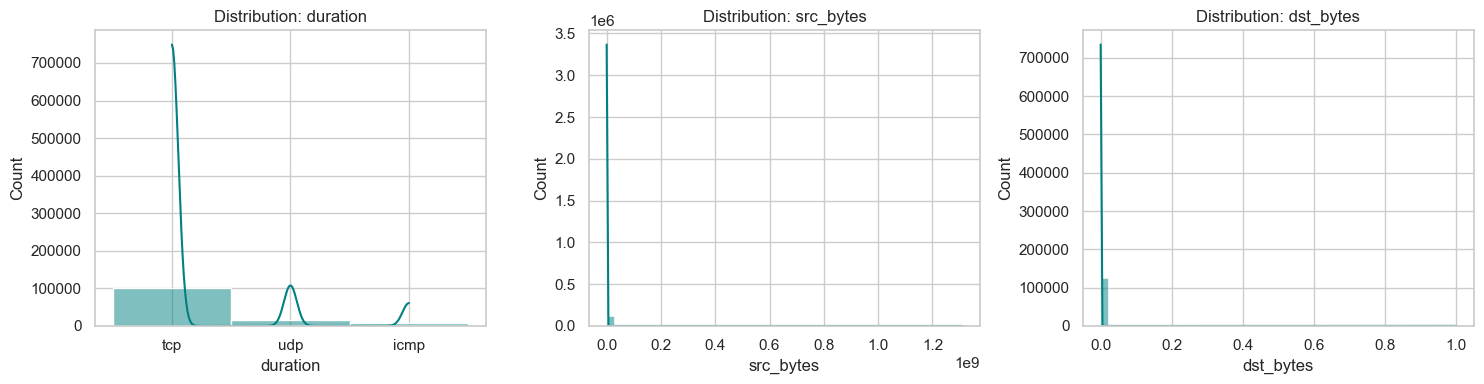

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_4940\2679823050.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


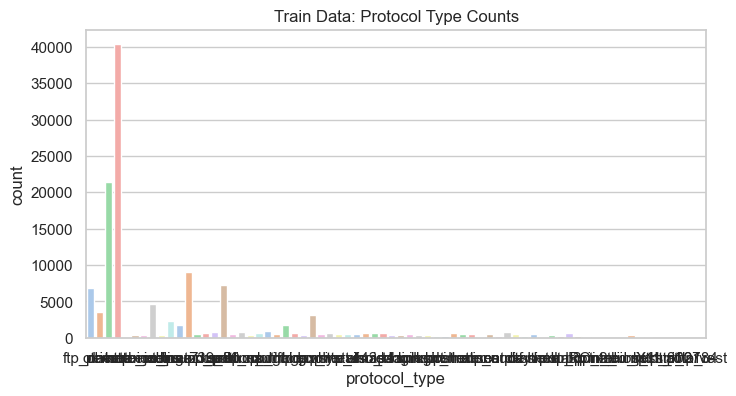

=== Binary Classification Results with Training & Testing Accuracy ===

Training Logistic Regression...
Training Accuracy: 0.9996
Testing Accuracy: 0.9945


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544


Training Decision Tree...
Training Accuracy: 1.0000
Testing Accuracy: 0.9945
Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9946    0.9999    0.9972     22421
      Normal     0.4000    0.0163    0.0312       123

    accuracy                         0.9945     22544
   macro avg     0.6973    0.5081    0.5142     22544
weighted avg     0.9914    0.9945    0.9920     22544


Training Random Forest...
Training Accuracy: 1.0000
Testing Accuracy: 0.9945


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544


Training SVM...
Training Accuracy: 0.9997
Testing Accuracy: 0.9945


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544



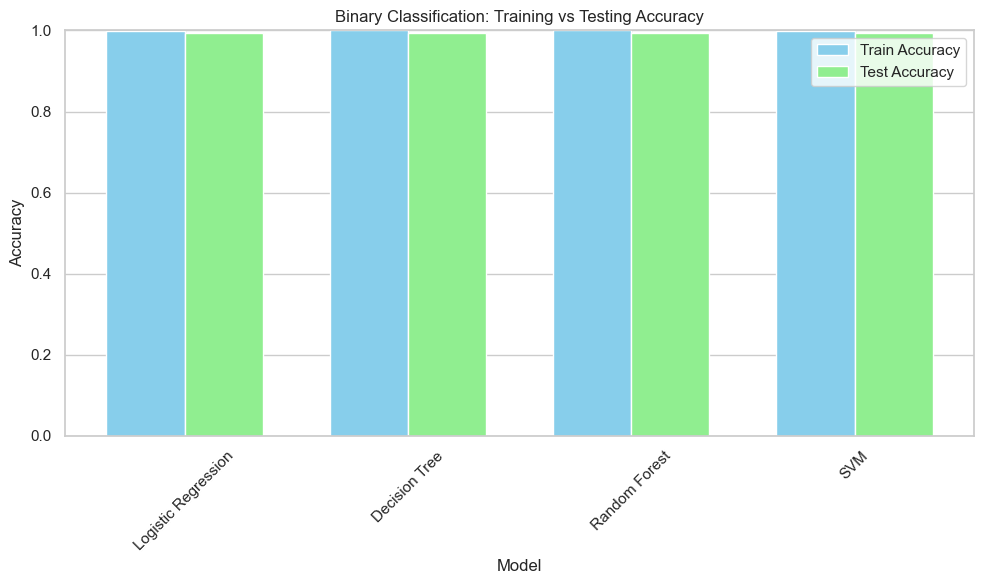

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set(style='whitegrid')

# Step 1: Load Dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Step 2: Visualize original label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Training Data Original Label Distribution')
plt.show()

# Step 3: Map labels to attack types (as per your mapping)
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Step 4: Visualize mapped label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')
plt.title('Train Data Labels After Mapping')
plt.show()

# Step 5: Drop duplicates
print(f"Train duplicates before: {train_df.duplicated().sum()}")
train_df.drop_duplicates(inplace=True)
print(f"Train duplicates after: {train_df.duplicated().sum()}")

# Step 6: Create binary label and visualize
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])
plt.title('Training Data Binary Label Distribution')
plt.show()

# Step 7: Define features and targets
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Step 8: Visualize numeric distributions
plt.figure(figsize=(15,4))
for i, col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Step 9: Visualize categorical feature distributions
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Train Data: Protocol Type Counts')
plt.show()

# Step 10: Convert numeric columns and handle missing values
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Step 11: Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(probability=True)
}

results = {}
print("=== Binary Classification Results with Training & Testing Accuracy ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    
    train_preds = model.predict(X_train_processed)
    test_preds = model.predict(X_test_processed)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc}
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Classification Report (Test):\n{classification_report(y_test, test_preds, digits=4)}")
# Visualize Train vs Test Accuracy
plt.figure(figsize=(10,6))
labels = list(results.keys())
train_scores = [results[name]['train_acc'] for name in labels]
test_scores = [results[name]['test_acc'] for name in labels]
bar_width = 0.35
import numpy as np
index = np.arange(len(labels))

plt.bar(index, train_scores, bar_width, label='Train Accuracy', color='skyblue')
plt.bar(index + bar_width, test_scores, bar_width, label='Test Accuracy', color='lightgreen')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Binary Classification: Training vs Testing Accuracy')
plt.xticks(index + bar_width / 2, labels, rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

Multi-class Classification: Train & Test Accuracy

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\744724031.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


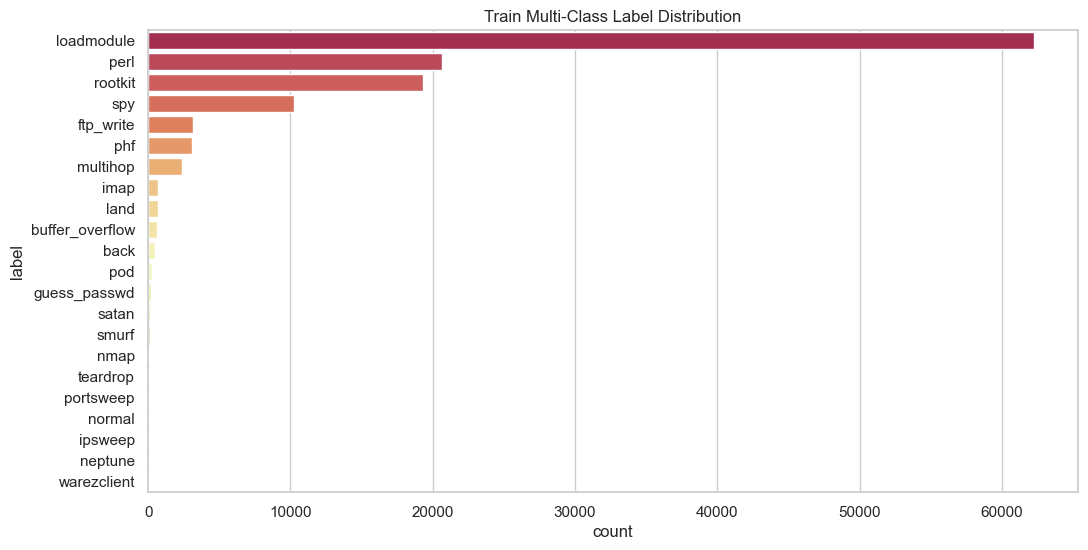

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\744724031.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette='coolwarm')


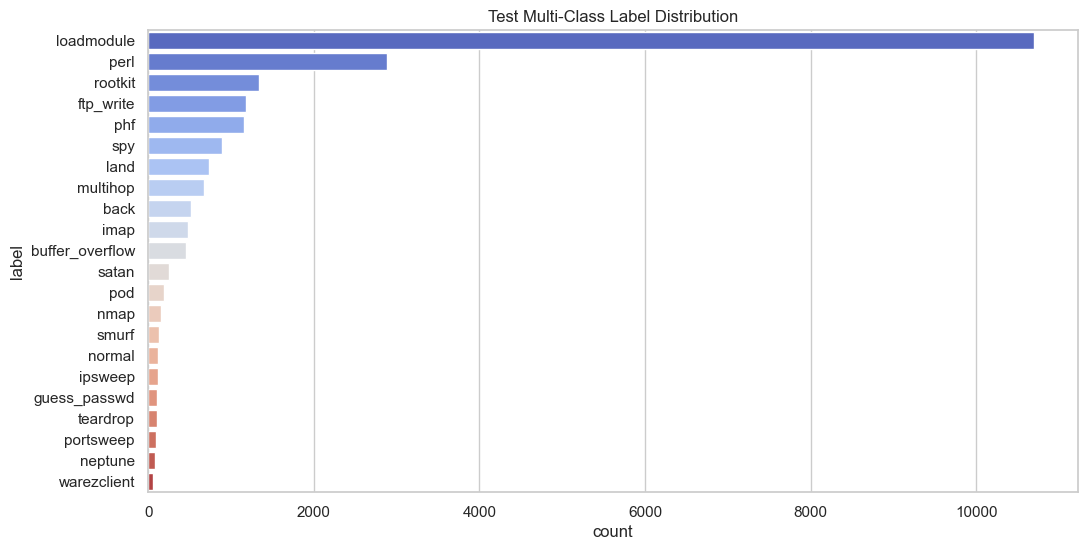

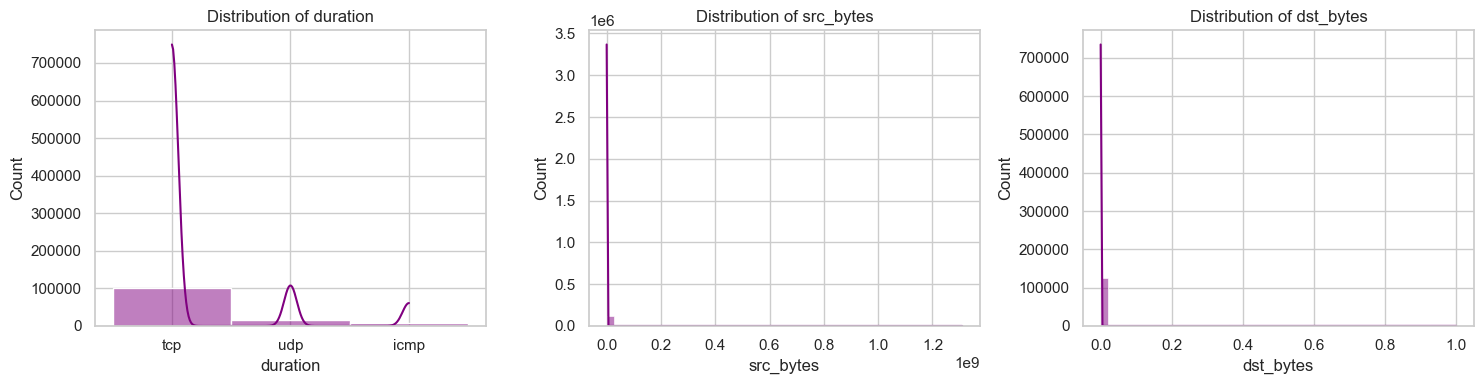

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26860\744724031.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


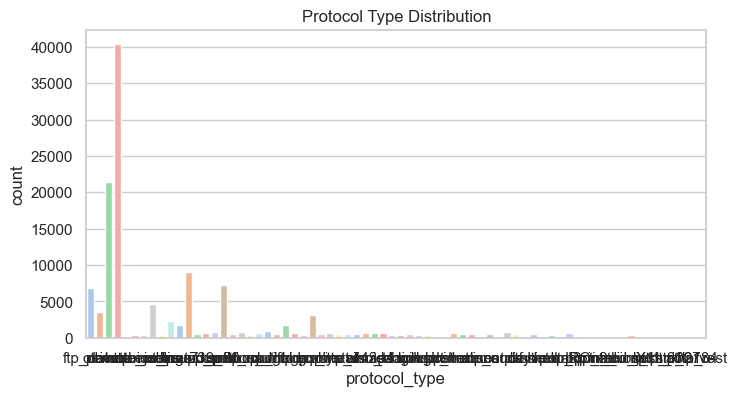

=== Multi-Class Classification Results with Training & Testing Accuracy ===

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.7077
Testing Accuracy: 0.5653


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       513
buffer_overflow     0.1250    0.0781    0.0961       461
      ftp_write     0.3609    0.0519    0.0907      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.1111    0.0041    0.0079       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0055    0.0014    0.0022       730
     loadmodule     0.7886    0.9587    0.8653     10694
       multihop     0.1378    0.0642    0.0876       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.3516    0.4424    0.3918      2882
            phf     0.1483    0.0269    0.0455      1154
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.0000    0.0000    0.0000       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0412    0.0078    0.0131       513
buffer_overflow     0.1273    0.0152    0.0271       461
      ftp_write     0.4741    0.1403    0.2165      1176
   guess_passwd     0.0303    0.0283    0.0293       106
           imap     0.1481    0.0165    0.0296       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1349    0.0397    0.0614       730
     loadmodule     0.7976    0.9748    0.8773     10694
       multihop     0.3231    0.1731    0.2255       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.1667    0.0064    0.0123       157
         normal     0.2500    0.0163    0.0305       123
           perl     0.5270    0.6627    0.5872      2882
            phf     0.3284    0.0763    0.1238      1154
            pod     0.1266    0.0513    0.0730       195
      portsweep     0.0135    0.0100    0.0115       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0387    0.0409    0.0398       513
buffer_overflow     0.1860    0.0174    0.0317       461
      ftp_write     0.3038    0.0204    0.0382      1176
   guess_passwd     0.0091    0.0283    0.0137       106
           imap     0.0484    0.0062    0.0109       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1739    0.0055    0.0106       730
     loadmodule     0.8055    0.9702    0.8802     10694
       multihop     0.1556    0.0627    0.0894       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1250    0.0163    0.0288       123
           perl     0.5142    0.5961    0.5521      2882
            phf     0.3134    0.1179    0.1713      1154
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.2000    0.0100    0.0190       100


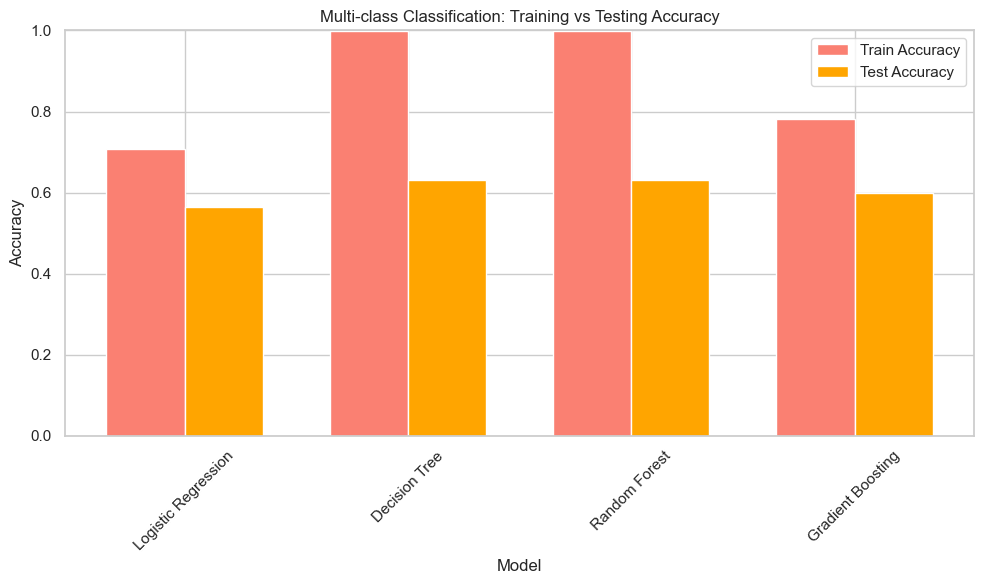

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
sns.set(style='whitegrid')

# Load data
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map labels to attack names
label_map = {
    0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
    6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
    12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
    18:'perl',19:'spy',20:'rootkit',21:'loadmodule'
}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Visualize multi-class distributions
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Train Multi-Class Label Distribution')
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index, palette='coolwarm')
plt.title('Test Multi-Class Label Distribution')
plt.show()

# Prepare features and target
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Visualize numeric feature histograms
plt.figure(figsize=(15,4))
for i,col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='purple')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualize categorical counts
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Protocol Type Distribution')
plt.show()

# Convert numeric, fill NA
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}
print("=== Multi-Class Classification Results with Training & Testing Accuracy ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    
    train_preds = model.predict(X_train_processed)
    test_preds = model.predict(X_test_processed)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc}
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Classification Report (Test):\n{classification_report(y_test, test_preds, digits=4)}")

# Visualize Train vs Test Accuracy
plt.figure(figsize=(10,6))
labels = list(results.keys())
train_scores = [results[name]['train_acc'] for name in labels]
test_scores = [results[name]['test_acc'] for name in labels]
bar_width = 0.35
import numpy as np
index = np.arange(len(labels))

plt.bar(index, train_scores, bar_width, label='Train Accuracy', color='salmon')
plt.bar(index + bar_width, test_scores, bar_width, label='Test Accuracy', color='orange')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Multi-class Classification: Training vs Testing Accuracy')
plt.xticks(index + bar_width / 2, labels, rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
best_model = models['Random Forest']
best_preds = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix (Random Forest - Binary Classification)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()